In [1]:
%autosave 0

Autosave disabled


# Testing Markov Chain Monte Carlo sampling algorithm

## Problem definition

Now, we turn our attention onto sampling methods. We start with the very well-known sampling method called MCMC. We are going to extract samples of the following probability density function (PDF):
\begin{equation}
\phi(\mathbf{x}) = k_1 \exp^{-\frac{1}{2}(\mathbf{x}-\mathbf{\mu}_1)^{T}\Sigma_1^{-1}(\mathbf{x}-\mathbf{\mu}_1)}+k_2 \exp^{-\frac{1}{2}(\mathbf{x}-\mathbf{\mu}_2)^{T}\Sigma_2^{-1}(\mathbf{x}-\mathbf{\mu}_2)},
\end{equation}
where two Gaussian multivariate distributions have been normalized summed together.

In [3]:
import sys
sys.path.insert(0, "../python")
import pyVector as Vec
from pyNonLinearSolver import MCMCsolver as MCMC
import pyProblem as Prblm
import numpy as np
# Plotting library
import matplotlib.pyplot as plt
#Plotting library
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
%matplotlib inline
params = {
    'image.interpolation': 'nearest',
    'image.cmap': 'gray',
    'savefig.dpi': 300,  # to adjust notebook inline plot size
    'axes.labelsize': 12, # fontsize for x and y labels (was 10)
    'axes.titlesize': 12,
    'font.size': 12, # was 10
    'legend.fontsize': 12, # was 10
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
}
matplotlib.rcParams.update(params)

WARNING! DATAPATH not found. The folder /tmp will be used to write binary files


We first start by writing the problem class definition.

In [4]:
class multi_gauss_prblm(Prblm.Problem):
    """
	   Objective function containing two Gaussian functions at two different centers in the 2D plane
	"""

    def __init__(self, mu1, mu2, sigma1, sigma2):
        """
        Objective function containing two gaussian functions with mu1, mu2, sigma1, and sigma2 parameters
        :param mu1: 1D array - mean of the gaussian function 1
        :param mu2: 1D array - mean of the gaussian function 2
        :param sigma1: 2D array - variance matrix of gaussian function 1
        :param sigma2: 2D array - variance matrix of gaussian function 2
        """
        # Setting the bounds (if any)
        super(multi_gauss_prblm, self).__init__(None, None)
        # Gaussian parameters
        self.mu1 = mu1
        self.mu2 = mu2
        self.sigma1_inv = np.linalg.inv(sigma1)
        self.sigma2_inv = np.linalg.inv(sigma2)
        self.scale1 = 0.5 / (np.sqrt(np.linalg.det(sigma1) * (2.0 * np.pi) ** self.mu1.shape[0]))
        self.scale2 = 0.5 / (np.sqrt(np.linalg.det(sigma2) * (2.0 * np.pi) ** self.mu2.shape[0]))
        # Setting initial model
        self.model = Vec.vectorIC(mu1.shape)
        self.dmodel = self.model.clone()
        self.dmodel.zero()
        # Gradient vector
        self.grad = self.dmodel.clone()
        # Residual vector
        self.res = Vec.vectorIC(np.array((0.,)))
        # Dresidual vector
        self.dres = self.res.clone()
        # Setting default variables
        self.setDefaults()
        self.linear = False
        return

    def objf(self, model):
        """Objective function computation"""
        m = model.arr  # Getting ndArray of the model
        obj = self.res.arr[0]
        return obj

    def resf(self, model):
        """Residual function"""
        m1 = model.getNdArray() - self.mu1
        m2 = model.getNdArray() - self.mu2
        self.res.getNdArray()[0] = self.scale1 * np.exp(-0.5 * np.dot(m1, np.dot(self.sigma1_inv, m1))) \
                            + self.scale2 * np.exp(-0.5 * np.dot(m2, np.dot(self.sigma2_inv, m2)))
        return self.res

### Instantiation of the inverse problem and of the MCMC solver/sampler

In [9]:
mu1 = np.array([2.0, 1.5])
mu2 = np.array([-1.5, -3.0])
sigma1 = np.array([[1., 3. / 5.], [3. / 5., 2.]])
sigma2 = np.array([[2., -3. / 5.], [-3. / 5., 1.]])
pdf_gauss_prb = multi_gauss_prblm(mu1, mu2, sigma1, sigma2)

Let's now perform an extensive search, which will help us understand how the sampling method is performing on this PDF.

In [30]:
#Computing the objective function for plotting
x_samples = np.linspace(-5.,5.,1000)
y_samples = np.linspace(-6.,6.,1000)
pdf_gauss = Vec.vectorIC(np.zeros((len(x_samples),len(y_samples))))
pdf_gaussNp = pdf_gauss.getNdArray()
sample_point = Vec.vectorIC(np.array((0.0,0.0)))
sample_pointNp = sample_point.getNdArray()
for ix,x_value in enumerate(x_samples):
	for iy,y_value in enumerate(y_samples):
		sample_pointNp[0] = x_value
		sample_pointNp[1] = y_value
		pdf_gaussNp[ix,iy]=pdf_gauss_prb.get_obj(sample_point)

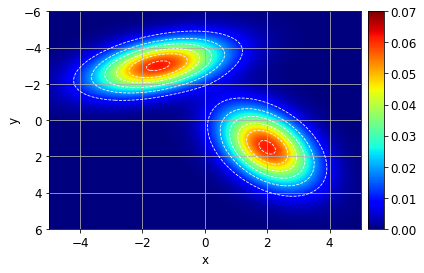

In [51]:
fig,ax=plt.subplots()
im=plt.imshow(pdf_gaussNp.T,cmap='jet',vmin=0.0,vmax=0.07,extent=[-5.,5.,6.,-6.0])
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
cs = plt.contour(np.flip(pdf_gaussNp.T,axis=0),levels=[0.01,0.02,0.03,0.04,0.05,0.06],extent=[-5.,5.,6.,-6.0],
                 colors="white",linewidths=(0.8,),linestyles=('--'))
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im, cax=cax)
ax.set_aspect('auto')

The next step is to sample the PDF with a MCMC method.

In [89]:
MCMCsampler = MCMC(nsamples=10000, prop_distr="Uni", max_step=5.0)
MCMCsampler.setDefaults(save_obj=True, save_model=True)
MCMCsampler.run(prblm, verbose=True)

##########################################################################################
Markov Chain Monte Carlo (MCMC) algorithm 
Restart folder: /tmp/restart_2020-05-04T14-07-43.582152/
##########################################################################################

sample number = 00001, obj = 1.35591e-02, resnorm = 1.36e-02, feval = 56092, acceptance rate = 1.0000e+00
sample number = 00002, obj = 1.35591e-02, resnorm = 1.36e-02, feval = 56093, acceptance rate = 5.0000e-01
sample number = 00003, obj = 2.51209e-02, resnorm = 2.51e-02, feval = 56094, acceptance rate = 6.6667e-01
sample number = 00004, obj = 2.51209e-02, resnorm = 2.51e-02, feval = 56095, acceptance rate = 5.0000e-01
sample number = 00005, obj = 2.51209e-02, resnorm = 2.51e-02, feval = 56096, acceptance rate = 4.0000e-01
sample number = 00006, obj = 2.51209e-02, resnorm = 2.51e-02, feval = 56097, acceptance rate = 3.3333e-01
sample number = 00007, obj = 2.51209e-02, resnorm = 2.51e-02, feval = 56098, acce

sample number = 00311, obj = 5.92493e-03, resnorm = 5.92e-03, feval = 56402, acceptance rate = 2.6045e-01
sample number = 00312, obj = 5.55577e-03, resnorm = 5.56e-03, feval = 56403, acceptance rate = 2.6282e-01
sample number = 00313, obj = 5.55577e-03, resnorm = 5.56e-03, feval = 56404, acceptance rate = 2.6198e-01
sample number = 00314, obj = 5.55577e-03, resnorm = 5.56e-03, feval = 56405, acceptance rate = 2.6115e-01
sample number = 00315, obj = 1.14467e-02, resnorm = 1.14e-02, feval = 56406, acceptance rate = 2.6349e-01
sample number = 00316, obj = 1.14467e-02, resnorm = 1.14e-02, feval = 56407, acceptance rate = 2.6266e-01
sample number = 00317, obj = 1.14467e-02, resnorm = 1.14e-02, feval = 56408, acceptance rate = 2.6183e-01
sample number = 00318, obj = 1.14467e-02, resnorm = 1.14e-02, feval = 56409, acceptance rate = 2.6101e-01
sample number = 00319, obj = 1.14467e-02, resnorm = 1.14e-02, feval = 56410, acceptance rate = 2.6019e-01
sample number = 00320, obj = 1.14467e-02, resn

sample number = 00784, obj = 1.77909e-02, resnorm = 1.78e-02, feval = 56875, acceptance rate = 2.3724e-01
sample number = 00785, obj = 3.15307e-02, resnorm = 3.15e-02, feval = 56876, acceptance rate = 2.3822e-01
sample number = 00786, obj = 3.15307e-02, resnorm = 3.15e-02, feval = 56877, acceptance rate = 2.3791e-01
sample number = 00787, obj = 3.15307e-02, resnorm = 3.15e-02, feval = 56878, acceptance rate = 2.3761e-01
sample number = 00788, obj = 3.15307e-02, resnorm = 3.15e-02, feval = 56879, acceptance rate = 2.3731e-01
sample number = 00789, obj = 3.15307e-02, resnorm = 3.15e-02, feval = 56880, acceptance rate = 2.3701e-01
sample number = 00790, obj = 3.15307e-02, resnorm = 3.15e-02, feval = 56881, acceptance rate = 2.3671e-01
sample number = 00791, obj = 3.15307e-02, resnorm = 3.15e-02, feval = 56882, acceptance rate = 2.3641e-01
sample number = 00792, obj = 3.15307e-02, resnorm = 3.15e-02, feval = 56883, acceptance rate = 2.3611e-01
sample number = 00793, obj = 3.15307e-02, resn

sample number = 01195, obj = 5.21991e-02, resnorm = 5.22e-02, feval = 57286, acceptance rate = 2.4017e-01
sample number = 01196, obj = 4.64311e-02, resnorm = 4.64e-02, feval = 57287, acceptance rate = 2.4080e-01
sample number = 01197, obj = 4.64311e-02, resnorm = 4.64e-02, feval = 57288, acceptance rate = 2.4060e-01
sample number = 01198, obj = 4.64311e-02, resnorm = 4.64e-02, feval = 57289, acceptance rate = 2.4040e-01
sample number = 01199, obj = 4.64311e-02, resnorm = 4.64e-02, feval = 57290, acceptance rate = 2.4020e-01
sample number = 01200, obj = 4.64311e-02, resnorm = 4.64e-02, feval = 57291, acceptance rate = 2.4000e-01
sample number = 01201, obj = 3.89371e-02, resnorm = 3.89e-02, feval = 57292, acceptance rate = 2.4063e-01
sample number = 01202, obj = 3.89371e-02, resnorm = 3.89e-02, feval = 57293, acceptance rate = 2.4043e-01
sample number = 01203, obj = 3.89371e-02, resnorm = 3.89e-02, feval = 57294, acceptance rate = 2.4023e-01
sample number = 01204, obj = 3.89371e-02, resn

sample number = 01646, obj = 1.23860e-02, resnorm = 1.24e-02, feval = 57737, acceptance rate = 2.3390e-01
sample number = 01647, obj = 1.23860e-02, resnorm = 1.24e-02, feval = 57738, acceptance rate = 2.3376e-01
sample number = 01648, obj = 1.59614e-02, resnorm = 1.60e-02, feval = 57739, acceptance rate = 2.3422e-01
sample number = 01649, obj = 1.59614e-02, resnorm = 1.60e-02, feval = 57740, acceptance rate = 2.3408e-01
sample number = 01650, obj = 1.59614e-02, resnorm = 1.60e-02, feval = 57741, acceptance rate = 2.3394e-01
sample number = 01651, obj = 4.86748e-02, resnorm = 4.87e-02, feval = 57742, acceptance rate = 2.3440e-01
sample number = 01652, obj = 4.86748e-02, resnorm = 4.87e-02, feval = 57743, acceptance rate = 2.3426e-01
sample number = 01653, obj = 4.86748e-02, resnorm = 4.87e-02, feval = 57744, acceptance rate = 2.3412e-01
sample number = 01654, obj = 2.19075e-02, resnorm = 2.19e-02, feval = 57745, acceptance rate = 2.3458e-01
sample number = 01655, obj = 2.19075e-02, resn

...

sample number = 08568, obj = 3.71234e-02, resnorm = 3.71e-02, feval = 64659, acceptance rate = 2.2327e-01
sample number = 08569, obj = 3.71234e-02, resnorm = 3.71e-02, feval = 64660, acceptance rate = 2.2325e-01
sample number = 08570, obj = 3.71234e-02, resnorm = 3.71e-02, feval = 64661, acceptance rate = 2.2322e-01
sample number = 08571, obj = 3.71234e-02, resnorm = 3.71e-02, feval = 64662, acceptance rate = 2.2319e-01
sample number = 08572, obj = 3.71234e-02, resnorm = 3.71e-02, feval = 64663, acceptance rate = 2.2317e-01
sample number = 08573, obj = 5.88940e-02, resnorm = 5.89e-02, feval = 64664, acceptance rate = 2.2326e-01
sample number = 08574, obj = 3.59281e-02, resnorm = 3.59e-02, feval = 64665, acceptance rate = 2.2335e-01
sample number = 08575, obj = 3.59281e-02, resnorm = 3.59e-02, feval = 64666, acceptance rate = 2.2332e-01
sample number = 08576, obj = 3.59281e-02, resnorm = 3.59e-02, feval = 64667, acceptance rate = 2.2330e-01
sample number = 08577, obj = 3.59281e-02, resn

sample number = 08951, obj = 2.49516e-02, resnorm = 2.50e-02, feval = 65042, acceptance rate = 2.2355e-01
sample number = 08952, obj = 1.74576e-02, resnorm = 1.75e-02, feval = 65043, acceptance rate = 2.2364e-01
sample number = 08953, obj = 1.74576e-02, resnorm = 1.75e-02, feval = 65044, acceptance rate = 2.2361e-01
sample number = 08954, obj = 1.74576e-02, resnorm = 1.75e-02, feval = 65045, acceptance rate = 2.2359e-01
sample number = 08955, obj = 1.74576e-02, resnorm = 1.75e-02, feval = 65046, acceptance rate = 2.2356e-01
sample number = 08956, obj = 1.74576e-02, resnorm = 1.75e-02, feval = 65047, acceptance rate = 2.2354e-01
sample number = 08957, obj = 2.67062e-02, resnorm = 2.67e-02, feval = 65048, acceptance rate = 2.2362e-01
sample number = 08958, obj = 2.67062e-02, resnorm = 2.67e-02, feval = 65049, acceptance rate = 2.2360e-01
sample number = 08959, obj = 2.67062e-02, resnorm = 2.67e-02, feval = 65050, acceptance rate = 2.2357e-01
sample number = 08960, obj = 2.67062e-02, resn

sample number = 09320, obj = 2.12542e-02, resnorm = 2.13e-02, feval = 65411, acceptance rate = 2.2457e-01
sample number = 09321, obj = 2.38144e-02, resnorm = 2.38e-02, feval = 65412, acceptance rate = 2.2465e-01
sample number = 09322, obj = 2.38144e-02, resnorm = 2.38e-02, feval = 65413, acceptance rate = 2.2463e-01
sample number = 09323, obj = 4.74687e-02, resnorm = 4.75e-02, feval = 65414, acceptance rate = 2.2471e-01
sample number = 09324, obj = 4.74687e-02, resnorm = 4.75e-02, feval = 65415, acceptance rate = 2.2469e-01
sample number = 09325, obj = 4.74687e-02, resnorm = 4.75e-02, feval = 65416, acceptance rate = 2.2466e-01
sample number = 09326, obj = 4.74687e-02, resnorm = 4.75e-02, feval = 65417, acceptance rate = 2.2464e-01
sample number = 09327, obj = 4.74687e-02, resnorm = 4.75e-02, feval = 65418, acceptance rate = 2.2462e-01
sample number = 09328, obj = 4.74687e-02, resnorm = 4.75e-02, feval = 65419, acceptance rate = 2.2459e-01
sample number = 09329, obj = 4.74687e-02, resn

sample number = 09643, obj = 3.42105e-02, resnorm = 3.42e-02, feval = 65734, acceptance rate = 2.2555e-01
sample number = 09644, obj = 1.00845e-02, resnorm = 1.01e-02, feval = 65735, acceptance rate = 2.2563e-01
sample number = 09645, obj = 4.17215e-02, resnorm = 4.17e-02, feval = 65736, acceptance rate = 2.2571e-01
sample number = 09646, obj = 4.17215e-02, resnorm = 4.17e-02, feval = 65737, acceptance rate = 2.2569e-01
sample number = 09647, obj = 4.17215e-02, resnorm = 4.17e-02, feval = 65738, acceptance rate = 2.2567e-01
sample number = 09648, obj = 4.17215e-02, resnorm = 4.17e-02, feval = 65739, acceptance rate = 2.2564e-01
sample number = 09649, obj = 4.17215e-02, resnorm = 4.17e-02, feval = 65740, acceptance rate = 2.2562e-01
sample number = 09650, obj = 4.29892e-02, resnorm = 4.30e-02, feval = 65741, acceptance rate = 2.2570e-01
sample number = 09651, obj = 4.29892e-02, resnorm = 4.30e-02, feval = 65742, acceptance rate = 2.2568e-01
sample number = 09652, obj = 4.29892e-02, resn

sample number = 09998, obj = 6.75134e-03, resnorm = 6.75e-03, feval = 66089, acceptance rate = 2.2505e-01
sample number = 09999, obj = 3.35253e-02, resnorm = 3.35e-02, feval = 66090, acceptance rate = 2.2512e-01
sample number = 10000, obj = 3.35253e-02, resnorm = 3.35e-02, feval = 66091, acceptance rate = 2.2510e-01
Number of tested samples reached maximum number of samples 10000
##########################################################################################
Markov Chain Monte Carlo (MCMC) algorithm algorithm end
##########################################################################################



In [87]:
#Converting sampled points to arrays for plotting
x_smpld=[MCMCsampler.model[iter].getNdArray()[0] for iter in range(len(MCMCsampler.model))]
y_smpld=[MCMCsampler.model[iter].getNdArray()[1] for iter in range(len(MCMCsampler.model))]

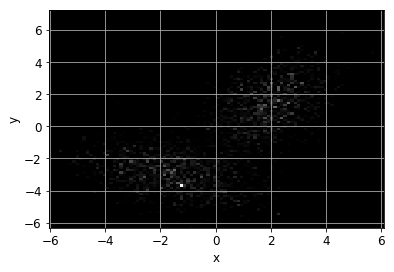

In [88]:
fig,ax=plt.subplots()
burn_samples=500
x=x_smpld[burn_samples:]
y=y_smpld[burn_samples:]
plt.hist2d(x,y, bins=100)
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
# cs = plt.contour(np.flip(pdf_gaussNp,axis=0),levels=[0.01,0.02,0.03,0.04,0.05,0.06],extent=[-5.,5.,6.,-6.0],
#                  colors="black",linewidths=(0.8,),linestyles=('--'))